<a href="https://colab.research.google.com/github/20230583/wed_2026_bigdatacomputing/blob/main/%EC%A4%91%EA%B0%84%EA%B3%A0%EC%82%AC_%ED%94%84%EB%A1%9C%EA%B7%B8%EB%9E%98%EB%B0%8D_%EA%B3%BC%EC%A0%9C_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# [중간고사 실기 과제] 시계열 기상 데이터 통합 분석 파이프라인 구축
1. 과제 개요

  - 본 과제는 실무 데이터 분석 프로세스를 경험하기 위해 웹상의 기상 데이터를 수집하고, 이를 기계학습 모델링이 가능한 형태의 '깨끗한 데이터'로 가공하는 통합 분석 파이프라인을 개별 함수 단위로 구현하기.

2. 데이터 소스

  - URL: https://github.com/dongupak/DataML/raw/main/csv/weather.csv

  - 주요 컬럼: 지점, 일시, 평균기온, 최대풍속, 평균풍속

3. 핵심 요구 사항 (평가 기준)

  - 모듈화 설계:
    - 모든 기능은 독립적인 함수로 작성되어야 하고,
    - main() 함수에서 제어되어야 함.

  - 데이터 정규화 (Min-Max Scaling):
    - 특정 수치 데이터를 0과 1 사이로 변환하는 함수를 포함해야 함.

  - 시계열 핸들링:
    - 날짜 변환, 인덱스 설정 및 7일 이동 평균 추세선을 생성해야 함.

  - 데이터 재구조화:
    - pivot_table과 groupby를 활용하여 다차원적인 통계량을 산출해야 함.

  - 엑셀 내보내기 (To Excel):
    - 분석 결과인 전처리 데이터, 계절별 통계, 연도별 피벗 테이블을 하나의 엑셀 파일(weather_analysis_report.xlsx)의 별도 시트에 각각 저장해야 함.

  - 다음과 같은 데이터분석 그래프을 생성해야 함.
  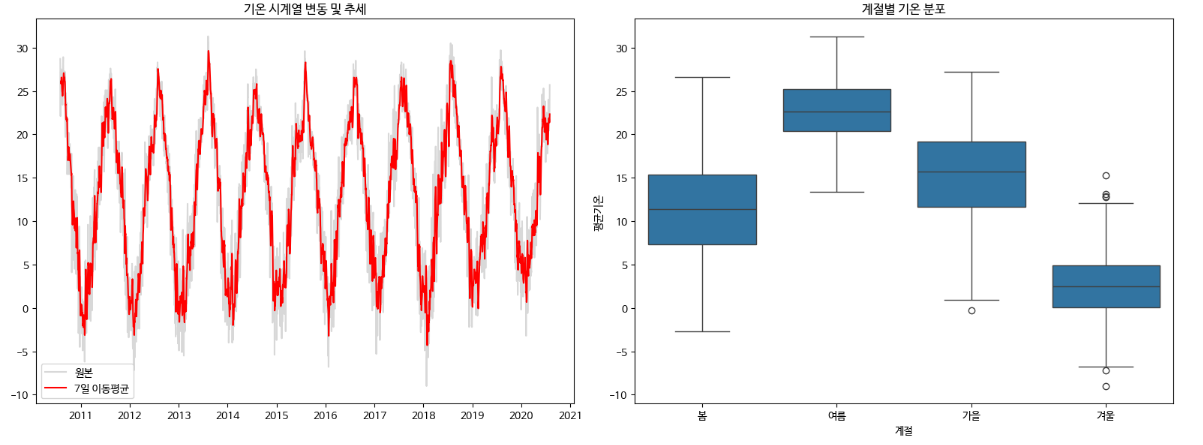

  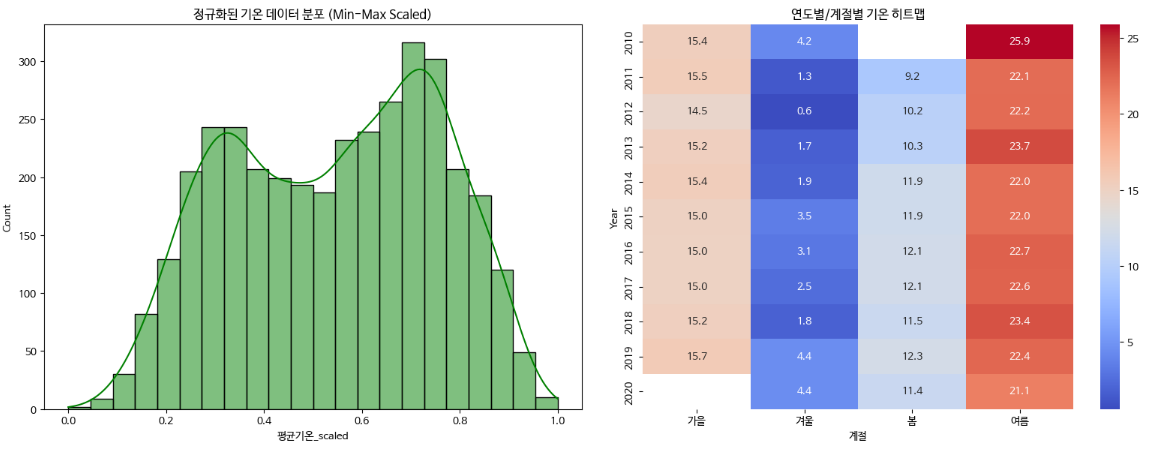



/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 50728 (\N{HANGUL SYLLABLE ON}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 50676 (\N{HANGUL SYLLABLE YEOL}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr

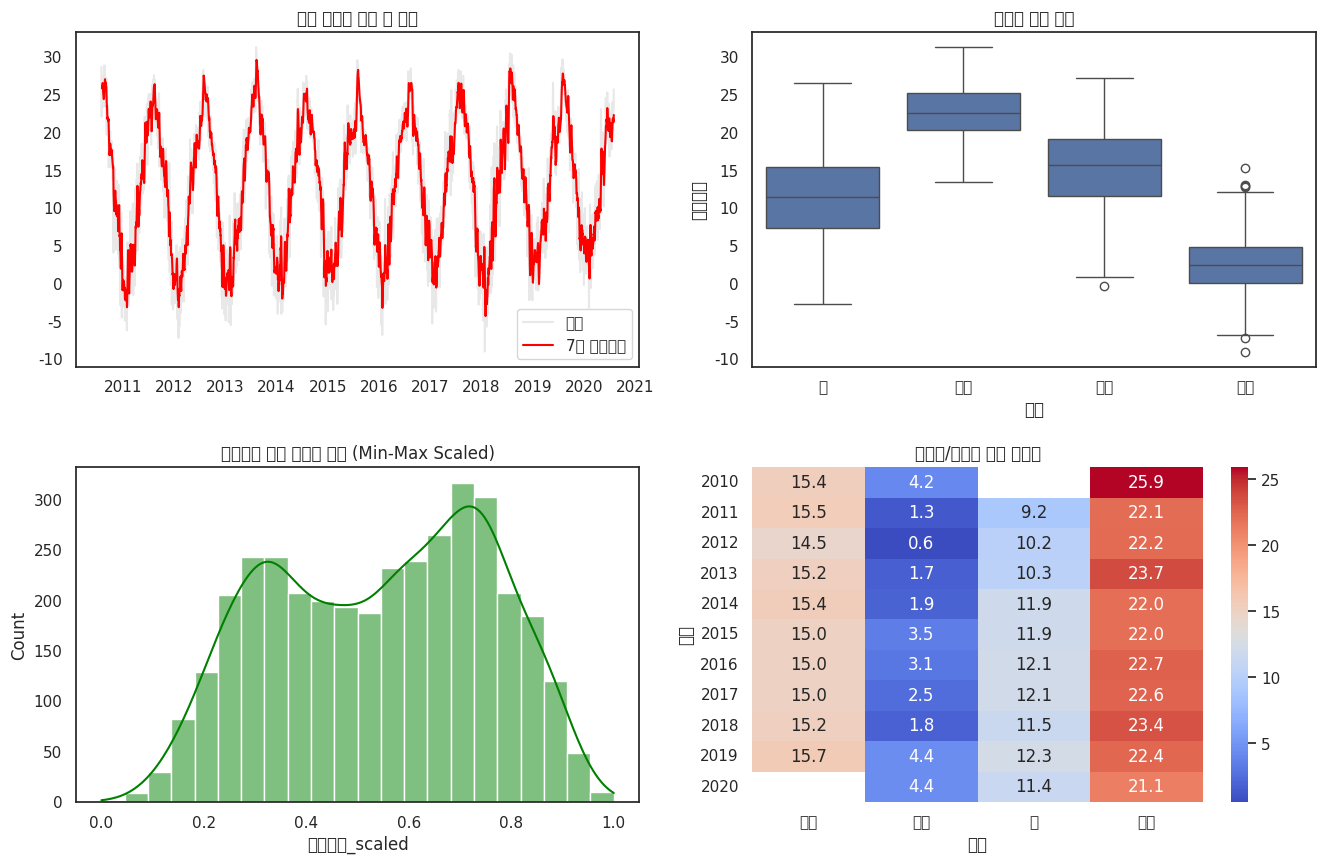

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

def load_data(url):
    df = pd.read_csv(url, encoding='cp949')
    df['일시'] = pd.to_datetime(df['일시'])
    return df

def preprocess_data(df):

    df = df.fillna(df.mean(numeric_only=True))

    df['7일 이동평균'] = df['평균기온'].rolling(window=7).mean()

    df['연도'] = df['일시'].dt.year
    df['월'] = df['일시'].dt.month

    def get_season(month):
        if month in [3, 4, 5]: return '봄'
        elif month in [6, 7, 8]: return '여름'
        elif month in [9, 10, 11]: return '가을'
        else: return '겨울'

    df['계절'] = df['월'].apply(get_season)
    return df

def normalize_data(df, column):
    scaler = MinMaxScaler()
    df[f'{column}_scaled'] = scaler.fit_transform(df[[column]])
    return df

def create_pivot_tables(df):
    season_stats = df.groupby('계절')['평균기온'].describe()

    year_season_pivot = df.pivot_table(values='평균기온', index='연도', columns='계절', aggfunc='mean')

    custom_order = ['가을', '겨울', '봄', '여름']
    year_season_pivot = year_season_pivot.reindex(columns=custom_order)

    return season_stats, year_season_pivot

def visualize_results(df, pivot_df):

    sns.set_theme(style="white", font='Malgun Gothic', rc={"axes.unicode_minus": False})

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    plt.subplots_adjust(hspace=0.3, wspace=0.2)

    axes[0, 0].plot(df['일시'], df['평균기온'], color='lightgray', label='원본', alpha=0.5)
    axes[0, 0].plot(df['일시'], df['7일 이동평균'], color='red', label='7일 이동평균')
    axes[0, 0].set_title("기온 시계열 변동 및 추세")
    axes[0, 0].legend()

    sns.boxplot(x='계절', y='평균기온', data=df, ax=axes[0, 1], order=['봄', '여름', '가을', '겨울'])
    axes[0, 1].set_title("계절별 기온 분포")
    axes[0, 1].set_ylabel("평균기온")

    sns.histplot(df['평균기온_scaled'], kde=True, color='green', ax=axes[1, 0])
    axes[1, 0].set_title("정규화된 기온 데이터 분포 (Min-Max Scaled)")
    axes[1, 0].set_xlabel("평균기온_scaled")

    sns.heatmap(pivot_df, annot=True, fmt=".1f", cmap='coolwarm', ax=axes[1, 1])
    axes[1, 1].set_title("연도별/계절별 기온 히트맵")
    axes[1, 1].set_xlabel("계절")
    axes[1, 1].set_ylabel("연도")

    plt.show()

def main():
    url = "https://github.com/dongupak/DataML/raw/main/csv/weather.csv"
    raw_data = load_data(url)
    processed_data = preprocess_data(raw_data)
    processed_data = normalize_data(processed_data, '평균기온')
    season_stats, pivot_df = create_pivot_tables(processed_data)
    visualize_results(processed_data, pivot_df)

if __name__ == "__main__":
    main()